# Clase 04 - Clasificar, explicar y comprobar

Las cuentas de B se trabajan con la presentación. Durante los 45 minutos, ejecútalas como comprobación y concentra tu interpretación en C y D. No necesitas un modelo guardado de la Clase 3.

## Preparación
En Colab abre este notebook y sube el CSV indicado al panel Archivos.

In [1]:
from pathlib import Path
import sys, subprocess, importlib.util, json, platform, hashlib, re, unicodedata
from importlib.metadata import version
necesarios = {"numpy":"numpy==2.2.6", "pandas":"pandas==2.2.3",
              "sklearn":"scikit-learn==1.6.1", "skops":"skops==0.11.0",
              "matplotlib":"matplotlib==3.10.3"}
faltan = [paquete for modulo,paquete in necesarios.items()
          if importlib.util.find_spec(modulo) is None]
if faltan:
    subprocess.run([sys.executable,"-m","pip","install",*faltan],check=True)
import numpy as np
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import skops.io as sio
import matplotlib.pyplot as plt
versiones = {p:version(p) for p in necesarios.values() for p in [p.split("==")[0]]}
versiones["python"] = platform.python_version()
print(versiones)
completados = set()
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay
import math

{'numpy': '2.5.3', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'skops': '0.11.0', 'matplotlib': '3.11.1', 'python': '3.12.10'}


## Datos y contrato
Lee `data/README.md`. Datos sintéticos originales, autorizados para docencia. `id` identifica el registro; `family` reúne variantes; `split` fija train/validation/test; `label` define acceso, pagos, conectividad o software; `text_original` conserva la fuente y `text_processed` aplica NFC y espacios.

Solo `text_processed` entra al modelo. Los identificadores y etiquetas no se añaden a las características. La clasificación orienta una revisión de soporte; no ejecuta acciones sobre cuentas ni pagos. Los ejemplos pequeños y repetitivos no representan toda la variedad del lenguaje real.

In [2]:
nombre = "corpus_clases_03_04.csv"
bases = [Path.cwd(), *Path.cwd().parents]
candidatos = [Path.cwd()/nombre]
for base in bases:
    candidatos += [base/"data"/nombre, base/"data"/nombre,
                   base/"data"/nombre]
ARCHIVO = next((p for p in candidatos if p.is_file()),None)
if ARCHIVO is None:
    raise FileNotFoundError("Extrae data/ junto al notebook o termina de subir el CSV al panel Archivos de Colab.")
df = pd.read_csv(ARCHIVO,keep_default_na=False,encoding="utf-8")
OUT = Path.cwd()/"resultados_clase04"
OUT.mkdir(exist_ok=True)
print("Fuente localizada:",ARCHIVO.name)

Fuente localizada: corpus_clases_03_04.csv


## A. Revisar las particiones
La siguiente comprobación revisa columnas, IDs únicos, campos completos y familias sin cruces. Lee los mensajes si falla: no elimines la comprobación para continuar.

Train sirve para aprender; validation para diagnosticar; test queda reservado. Contar las filas de test para revisar el contrato no equivale a predecirlo ni evaluarlo.

In [3]:
def comprobar_particiones(tabla):
    obligatorias = {"id","family","split","label","text_original","text_processed"}
    assert obligatorias <= set(tabla.columns), "Faltan columnas del contrato"
    assert tabla.id.is_unique, "IDs repetidos"
    assert not tabla[list(obligatorias)].isna().any().any(), "Hay ausencias"
    for col in obligatorias:
        assert tabla[col].astype(str).str.strip().ne("").all(), "Campo vacío: "+col
    assert set(tabla.split)=={"train","validation","test"}, "Revisar particiones"
    for col in ["family","text_processed"]:
        if tabla.groupby(col).split.nunique().max()>1:
            raise ValueError("Fuga por "+col)
    grupos = {s:tabla[tabla.split==s].copy() for s in ["train","validation","test"]}
    etiquetas = sorted(grupos["train"].label.unique())
    assert len(etiquetas)>=2
    for s,parte in grupos.items():
        assert set(parte.label)==set(etiquetas), "Cobertura distinta: "+s
    return grupos,etiquetas
partes, LABELS = comprobar_particiones(df)
train, val, test = [partes[s] for s in ["train","validation","test"]]
print(df.groupby("split").agg(filas=("id","size"),familias=("family","nunique")))
print(pd.crosstab(df.split,df.label).reindex(columns=LABELS))
completados.add(1)

            filas  familias
split                      
test           24         8
train          96        32
validation     24         8
label       acceso  conectividad  pagos  software
split                                            
test             6             6      6         6
train           24            24     24        24
validation       6             6      6         6


**Cómo leer la salida.** Hay 96 filas de entrenamiento, 24 de validación y 24 reservadas para prueba. Cada familia permanece en una sola partición. Solo `text_processed` entra como texto al modelo; `label` se utiliza como referencia de entrenamiento y evaluación.

## B1. Naive Bayes: de documentos a conteos

Ejemplo didáctico separado del corpus real. D1 es acceso: “clave clave clave pago”. D2 es pagos: “clave pago pago pago”. Las columnas serán [clave, pago]. Un conteo de 3 significa tres apariciones dentro de ese documento.

In [4]:
textos_toy = ["clave clave clave pago", "clave pago pago pago"]
etiquetas_toy = ["acceso", "pagos"]
contador_toy = CountVectorizer()
conteos_toy = contador_toy.fit_transform(textos_toy)
display(pd.DataFrame(conteos_toy.toarray(), columns=contador_toy.get_feature_names_out(), index=etiquetas_toy))
assert conteos_toy.toarray().tolist() == [[3,1],[1,3]]

,clave,pago
acceso,3,1
pagos,1,3


**Cómo leer la salida.** Cada fila tiene cuatro apariciones. Hay un documento por clase entre dos documentos: la probabilidad previa de cada clase es 1/2. Esta cuenta de documentos es distinta de sumar palabras.

## B2. Probabilidad condicional y suavizado

`P(clave | acceso)` se lee “probabilidad de clave dado acceso”: en este modelo describe la frecuencia del término dentro de la clase. `P(acceso | clave)` pregunta por la clase después de observar el término; no son la misma pregunta.

Alpha es la cantidad añadida a **cada** conteo. Con alpha=1 y dos términos, cada total aumenta 1×2. El denominador es 4+2=6. La independencia condicional supone que, conocida la clase, combinamos las señales de las palabras como si no dependieran entre sí; “no puedo” recuerda que el lenguaje real puede contradecir esa simplificación.

In [5]:
alpha = 1.0
tam_vocabulario = 2
denominador = 4 + alpha * tam_vocabulario
p_clave_acceso = (3 + alpha) / denominador
p_clave_pagos = (1 + alpha) / denominador
print("Denominador:", denominador)
print("P(clave | acceso) = 4/6 =", p_clave_acceso)
print("P(clave | pagos) = 2/6 =", p_clave_pagos)

Denominador: 6.0
P(clave | acceso) = 4/6 = 0.6666666666666666
P(clave | pagos) = 2/6 = 0.3333333333333333


**Cómo leer la salida.** Se añadió 1 a clave y 1 a pago en cada clase. No se añade 1 una sola vez al total. Incluso un conteo originalmente cero recibiría una probabilidad positiva.

## B3. Scores, normalización y decisión

Un score es un valor para comparar alternativas. Para un documento nuevo con una sola palabra, "clave", multiplicamos la probabilidad previa por la probabilidad del término. Luego dividimos cada score entre la suma.

In [6]:
scores_toy = np.array([0.5*p_clave_acceso, 0.5*p_clave_pagos])
suma_scores = scores_toy.sum()
posterior_manual = scores_toy / suma_scores
print("Scores (acceso, pagos):", scores_toy)  # 1/3 y 1/6
print("Suma:", suma_scores)                  # 1/2
print("Probabilidades:", posterior_manual)  # 2/3 y 1/3
nb_toy = MultinomialNB(alpha=1.0)
nb_toy.fit(conteos_toy, etiquetas_toy)
posterior_biblioteca = nb_toy.predict_proba(contador_toy.transform(["clave"]))[0]
assert nb_toy.classes_.tolist() == ["acceso","pagos"]
assert np.allclose(posterior_manual, posterior_biblioteca)
print("Clase elegida:", nb_toy.predict(contador_toy.transform(["clave"]))[0])

Scores (acceso, pagos): [0.33333333 0.16666667]
Suma: 0.5
Probabilidades: [0.66666667 0.33333333]
Clase elegida: acceso


**Cómo leer la salida.** (1/3)/(1/2)=2/3; (1/6)/(1/2)=1/3. Se elige acceso porque obtiene la mayor probabilidad del modelo. No es una garantía de acierto en el mundo real. MultinomialNB admite TF-IDF no negativo como uso práctico, pero esos pesos ya no son los conteos enteros de este ejemplo.

## B4. Logística: multiplicar posiciones y sumar

`x` es el vector de entrada; `w` son los pesos; `b` es el intercepto, un ajuste que se suma aunque una característica valga cero. `z` es el score. El producto punto multiplica cada posición y suma sus aportes. Estos pesos se eligieron para explicar, no se entrenaron. Definimos acceso como la clase positiva de este ejemplo binario.

In [7]:
x = np.array([1.,0.])
w = np.array([2.,-1.])
b = -1.
aportes = w*x
z = aportes.sum()+b
print("Aportes:", aportes, "suma:", aportes.sum(), "intercepto:", b, "z:", z)
assert z == 1 and np.isclose(w@x+b,z)

Aportes: [ 2. -0.] suma: 2.0 intercepto: -1.0 z: 1.0


**Cómo leer la salida.** (2×1)+(-1×0)+(-1)=2+0-1=1. El operador `@` realiza el producto punto; aquí comprobamos que coincide con multiplicar y sumar explícitamente.

## B5. Exp y sigmoide: de z a una probabilidad

`exp(a)` significa e elevado a a, con e≈2.71828. Es la operación inversa de ln: exp(ln(2))=2. Un exponente negativo indica un recíproco: exp(-1)=1/e.

Para z=1, primero calcula exp(-1), luego suma 1 y al final divide 1 entre ese resultado. En calculadora usa la función eˣ; en Python, `math.exp` o `np.exp`.

In [8]:
exponencial = math.exp(-z)
denominador_sigmoide = 1+exponencial
p_acceso_toy = 1/denominador_sigmoide
print("exp(-1):",exponencial)
print("1 + exp(-1):",denominador_sigmoide)
print("p(acceso):",p_acceso_toy,"p(pagos):",1-p_acceso_toy)
assert np.isclose(p_acceso_toy,0.7310585786300049)
assert np.isclose(math.exp(math.log(2)),2)

exp(-1): 0.36787944117144233
1 + exp(-1): 1.3678794411714423
p(acceso): 0.7310585786300049 p(pagos): 0.2689414213699951


**Cómo leer la salida.** 0.367879 aproximadamente; después 1.367879; finalmente 0.731059 para acceso. Estos números se redondean solo al mostrarlos. La sigmoide ilustrada es binaria; el modelo real de cuatro clases necesita una normalización entre clases.

## B6. Cuatro clases: normalización softmax

Softmax transforma los scores de todas las clases en probabilidades cuya suma es 1: exponencia cada score y divide entre la suma de exponenciales. Este ejemplo de scores también está elegido a mano; no representa un entrenamiento real.

In [9]:
clases_demo = ["acceso","conectividad","pagos","software"]
scores_demo = np.array([1.,0.,-1.,0.])
exp_demo = np.exp(scores_demo)
probas_demo = exp_demo/exp_demo.sum()
display(pd.DataFrame({"clase":clases_demo,"score":scores_demo,"exp(score)":exp_demo,"probabilidad":probas_demo}))
print("Suma de exponenciales:",exp_demo.sum(),"suma de probabilidades:",probas_demo.sum())
assert np.isclose(probas_demo.sum(),1)

,clase,score,exp(score),probabilidad
0,acceso,1.0,2.718282,0.534447
1,conectividad,0.0,1.000000,0.196612
2,pagos,-1.0,0.367879,0.072329
3,software,0.0,1.000000,0.196612


Suma de exponenciales: 5.086161269630487 suma de probabilidades: 1.0


**Cómo leer la salida.** Se elige la mayor probabilidad: acceso. Para el entrenamiento multiclase real con lbfgs se aprende un score por clase. Más adelante comprobamos esta normalización contra `predict_proba` con el modelo ya ajustado. No aplicamos cuatro sigmoides independientes.

## B7. Construir y leer la matriz ilustrativa

Las filas contienen las etiquetas reales y las columnas las predicciones. Usamos acceso y pagos, en ese orden. La diagonal indica aciertos; las otras celdas indican errores.

In [10]:
clases_toy = ["acceso","pagos"]
real = ["acceso"]*10+["pagos"]*10
pred = ["acceso"]*8+["pagos"]*2+["acceso"]*4+["pagos"]*6
cm_toy = confusion_matrix(real,pred,labels=clases_toy)
display(pd.DataFrame(cm_toy,index=["Real acceso","Real pagos"],columns=["Pred. acceso","Pred. pagos"]))
assert cm_toy.tolist() == [[8,2],[4,6]]

,Pred. acceso,Pred. pagos
Real acceso,8,2
Real pagos,4,6


**Cómo leer la salida.** 8 accesos acertados; 2 accesos enviados a pagos; 4 pagos enviados a acceso; 6 pagos acertados. Hay 20 casos, 14 aciertos y 6 errores. Support es el número de casos reales: cada fila suma 10.

## B8. Elegir la clase positiva y contar TP, FP, FN, TN

Positiva significa la clase que estamos examinando: aquí pagos. TP es verdadero positivo, FP falso positivo, FN falso negativo y TN verdadero negativo. Marca la celda de pagos con pagos, su columna, su fila y lo que queda fuera de ambas.

In [11]:
tp,fp,fn,tn = 6,2,4,8
print({"TP":tp,"FP":fp,"FN":fn,"TN":tn})
assert tp+fp+fn+tn == cm_toy.sum()

{'TP': 6, 'FP': 2, 'FN': 4, 'TN': 8}


**Cómo leer la salida.** TP: pagos encontrados; FP: otros enviados a pagos; FN: pagos que se perdieron; TN: otros correctamente excluidos. Si cambias la clase positiva, debes volver a localizar esos conteos.

## B9. Accuracy, precision y recall, con denominadores

Accuracy pregunta cuántos casos totales acertamos. Precision pregunta qué parte de lo predicho como pagos era pagos. Recall pregunta qué parte de los pagos reales encontramos. Sus denominadores responden preguntas distintas.

In [12]:
accuracy_toy = (tp+tn)/(tp+fp+fn+tn)
precision_toy = tp/(tp+fp)
recall_toy = tp/(tp+fn)
print("Accuracy = 14/20:",accuracy_toy)
print("Precision pagos = 6/8:",precision_toy)
print("Recall pagos = 6/10:",recall_toy)

Accuracy = 14/20: 0.7
Precision pagos = 6/8: 0.75
Recall pagos = 6/10: 0.6


**Cómo leer la salida.** Accuracy=0.70; precision=0.75; recall=0.60. Precision recorre la columna pagos; recall recorre la fila pagos. Un promedio global no identifica qué clase sufre los errores.

## B10. F1, clase acceso, macro y weighted

P representa precision y R recall. F1=2PR/(P+R): multiplica 2×P×R y divide entre P+R. Es una media armónica; no coincide con (P+R)/2. Para acceso, TP=8, FP=4, FN=2 y TN=6.

In [13]:
numerador_f1 = 2*precision_toy*recall_toy
denominador_f1 = precision_toy+recall_toy
f1_pagos = numerador_f1/denominador_f1
p_acc,r_acc = 8/12,8/10
f1_acceso = 2*p_acc*r_acc/(p_acc+r_acc)
f1_macro_toy = (f1_acceso+f1_pagos)/2
f1_weighted_toy = (10*f1_acceso+10*f1_pagos)/20
print("F1 pagos:",numerador_f1,"/",denominador_f1,"=",f1_pagos)
print("Acceso: precision, recall, F1:",p_acc,r_acc,f1_acceso)
print("Macro:",f1_macro_toy,"Weighted:",f1_weighted_toy)
rep_toy = classification_report(real,pred,labels=clases_toy,output_dict=True,zero_division=0)
assert np.isclose(rep_toy["pagos"]["f1-score"],f1_pagos)
assert np.isclose(rep_toy["acceso"]["f1-score"],f1_acceso)
assert np.isclose(rep_toy["macro avg"]["f1-score"],f1_macro_toy)
display(pd.DataFrame(rep_toy).T)

F1 pagos: 0.8999999999999999 / 1.35 = 0.6666666666666665
Acceso: precision, recall, F1: 0.6666666666666666 0.8 0.7272727272727272
Macro: 0.6969696969696968 Weighted: 0.6969696969696969


,precision,recall,f1-score,support
acceso,0.666667,0.8,0.727273,10.0
pagos,0.750000,0.6,0.666667,10.0
accuracy,0.700000,0.7,0.700000,0.7
macro avg,0.708333,0.7,0.696970,20.0
weighted avg,0.708333,0.7,0.696970,20.0


**Cómo leer la salida.** F1 pagos≈0.666667; F1 acceso≈0.727273; F1 macro≈0.696970. Macro da igual peso a cada clase; weighted utiliza sus supports. Aquí coinciden porque ambos supports son 10. F1 macro no se obtiene a partir de precision macro y recall macro.

## B11. ¿Qué sucede si un denominador es cero?

Si nunca predigo pagos, TP+FP=0 y su precision queda indefinida. La opción `zero_division=0` registra 0 para ese caso; no inventa un acierto ni demuestra que la clase no exista.

In [14]:
rep_cero = classification_report(["acceso","pagos"],["acceso","acceso"],labels=clases_toy,output_dict=True,zero_division=0)
print("Precision pagos sin predicciones de pagos:",rep_cero["pagos"]["precision"])
assert rep_cero["pagos"]["precision"] == 0

Precision pagos sin predicciones de pagos: 0.0


**Cómo leer la salida.** Hay un pago real que se perdió. Declarar la convención del cero permite interpretar el reporte sin confundir ausencia de predicciones con ausencia de casos.

## C. Modelo real: un solo clasificador
Ahora dejamos los ejemplos elegidos a mano. `Pipeline` encadena TF-IDF y regresión logística. TF-IDF produce características; el clasificador aprende a relacionarlas con categorías.

`C=1` controla inversamente la regularización: un C menor penaliza más los pesos grandes. `max_iter=1000` limita iteraciones; `solver="lbfgs"` elige el método de ajuste. No cambiaremos estas opciones mirando test. Si aparece una advertencia de convergencia, hay que revisarla.

In [15]:
SEED = 42
vectorizador = TfidfVectorizer(ngram_range=(1,1),lowercase=True,strip_accents=None,
                              stop_words=None,norm="l2",smooth_idf=True,sublinear_tf=False)
clasificador = LogisticRegression(C=1.0,max_iter=1000,solver="lbfgs",random_state=SEED)
model = Pipeline([("tfidf",vectorizador),("clasificador",clasificador)])
print(model)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clasificador',
                 LogisticRegression(max_iter=1000, random_state=42))])


## C1. Entrenar solo con train

`fit` recibe textos y etiquetas de train. Primero aprende vocabulario e IDF; después aprende los pesos del clasificador con esos vectores y etiquetas. La salida es un objeto con ese estado aprendido.

In [16]:
model.fit(train.text_processed,train.label)
vocab_antes = model["tfidf"].vocabulary_.copy()
idf_antes = model["tfidf"].idf_.copy()
print("Características aprendidas:",len(vocab_antes))
print("Clases aprendidas:",model.classes_)

Características aprendidas: 142
Clases aprendidas: ['acceso' 'conectividad' 'pagos' 'software']


**Cómo leer la salida.** Un término es una característica de entrada; una clase es una categoría de salida. Los números de columnas y clases pueden ser distintos. Las etiquetas no se concatenan al texto.

## C2. Predecir y leer predict_proba

`predict` devuelve etiquetas y `predict_proba` devuelve una columna por clase. El orden lo determina `classes_`, no el orden que recuerdes de memoria. Se aplica el estado guardado; no se llama otra vez a fit.

In [17]:
pred_val = model.predict(val.text_processed)
probas_val = model.predict_proba(val.text_processed)
LABELS = model.classes_.tolist()
assert model["tfidf"].vocabulary_ == vocab_antes
assert np.array_equal(model["tfidf"].idf_,idf_antes)
assert np.allclose(probas_val.sum(axis=1),1)
predicciones = val[["id","family","text_original","text_processed","label"]].copy()
predicciones["prediction"] = pred_val
display(predicciones.head(3))
display(pd.DataFrame(probas_val[:3],columns=LABELS,index=val.id.iloc[:3]))

,id,family,text_original,text_processed,label,prediction
24,S025,G009,La página regresa al inicio de sesión sin avisar.,La página regresa al inicio de sesión sin avisar.,acceso,acceso
25,S026,G009,"Buen día, la página regresa al inicio de sesió...","Buen día, la página regresa al inicio de sesió...",acceso,acceso
26,S027,G009,La página regresa al inicio de sesión sin avis...,La página regresa al inicio de sesión sin avis...,acceso,acceso


,acceso,conectividad,pagos,software
id,,,,
S025,0.344865,0.198362,0.207852,0.248921
S026,0.323806,0.197977,0.228038,0.250178
S027,0.323749,0.200840,0.222963,0.252448


**Cómo leer la salida.** Cada fila corresponde al mismo ID mostrado en la tabla de textos. La etiqueta elegida corresponde a la probabilidad máxima. Una probabilidad del modelo no garantiza ese porcentaje de aciertos en datos nuevos.

## C3. Conectar texto, vector y decisión

Tomamos la primera fila de validación como ejemplo guiado. `transform` pertenece al vectorizador; nuestro Pipeline completo termina en un clasificador. `getrow(0)` extrae una fila sin volver densa toda la matriz.

In [18]:
registro_guiado = val.iloc[0]
fila_guiada = model["tfidf"].transform([registro_guiado.text_processed]).getrow(0)
nombres = model["tfidf"].get_feature_names_out()
tabla_guiada = pd.DataFrame({"termino":nombres[fila_guiada.indices],"peso":fila_guiada.data}).sort_values("peso",ascending=False)
print("ID:",registro_guiado.id,"Texto:",registro_guiado.text_processed)
display(tabla_guiada.head(6))
print("Etiqueta real:",registro_guiado.label,"Predicción:",pred_val[0])
# La normalización multiclase coincide con la biblioteca.
scores_reales = model.decision_function([registro_guiado.text_processed])[0]
exp_estables = np.exp(scores_reales-scores_reales.max())
assert np.allclose(exp_estables/exp_estables.sum(),probas_val[0])

ID: S025 Texto: La página regresa al inicio de sesión sin avisar.


,termino,peso
3,sesión,0.701346
0,al,0.547914
1,de,0.358462
2,la,0.281798


Etiqueta real: acceso Predicción: acceso


**Cómo leer la salida.** El peso TF-IDF describe esa representación del texto, no la probabilidad de la clase ni una causa. Para verificar softmax restamos el máximo antes de exponenciar: evita números enormes y no cambia las proporciones finales.

## C4. Dibujar la matriz de cuatro clases

Comparamos `label` con `prediction` usando el mismo orden de clases en ambos ejes. Esta matriz sí procede de la ejecución del corpus; la matriz de veinte casos era ilustrativa.

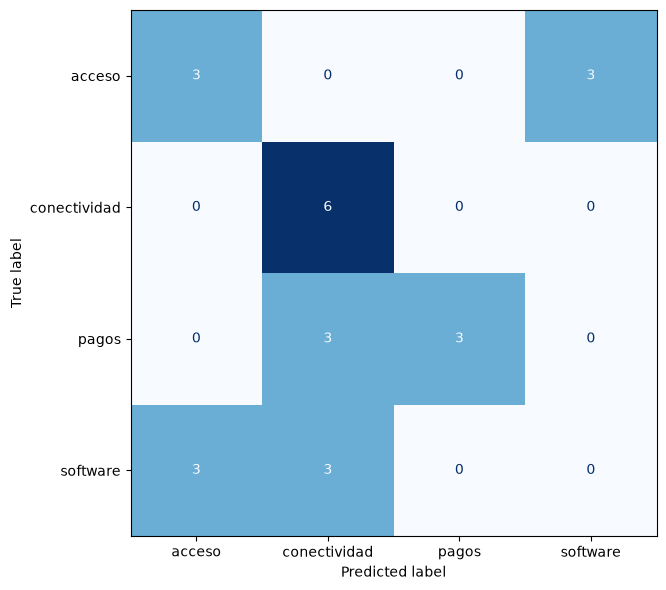

,precision,recall,f1-score,support
acceso,0.5,0.5,0.500000,6.0
conectividad,0.5,1.0,0.666667,6.0
pagos,1.0,0.5,0.666667,6.0
software,0.0,0.0,0.000000,6.0
accuracy,0.5,0.5,0.500000,0.5
macro avg,0.5,0.5,0.458333,24.0
weighted avg,0.5,0.5,0.458333,24.0


Accuracy: 0.5 F1 macro: 0.45833333333333326


In [19]:
cm_val = confusion_matrix(val.label,pred_val,labels=LABELS)
reporte_val = classification_report(val.label,pred_val,labels=LABELS,output_dict=True,zero_division=0)
accuracy_val = accuracy_score(val.label,pred_val)
f1_macro_val = f1_score(val.label,pred_val,labels=LABELS,average="macro",zero_division=0)
fig,ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(cm_val,display_labels=LABELS).plot(ax=ax,cmap="Blues",values_format="d",colorbar=False)
plt.tight_layout();fig.savefig(OUT/"matriz_validacion.png",dpi=150);plt.show();plt.close(fig)
display(pd.DataFrame(reporte_val).T)
print("Accuracy:",accuracy_val,"F1 macro:",f1_macro_val)
resultado_val = {"accuracy":float(accuracy_val),"f1_macro":float(f1_macro_val),"por_clase":reporte_val,
                 "confusion":cm_val.tolist(),"orden_clases":LABELS,"filas":"reales","columnas":"predichas"}

**Cómo leer la salida.** La diagonal suma los aciertos. Las sumas de filas son casos reales y las de columnas son predicciones. El promedio no sustituye leer qué clase se pierde. La evaluación de test permanece pendiente para otro protocolo.

## C5. Una clase frente al resto

Aunque haya cuatro clases, para una clase podemos contar TP, FP y FN. TP es su diagonal; FP es el resto de su columna; FN es el resto de su fila. Elegirás otra clase para practicar esta lectura.

In [20]:
i_guiado = LABELS.index("acceso")
tp_g = int(cm_val[i_guiado,i_guiado])
fp_g = int(cm_val[:,i_guiado].sum()-tp_g)
fn_g = int(cm_val[i_guiado,:].sum()-tp_g)
tn_g = int(cm_val.sum()-tp_g-fp_g-fn_g)
p_g = tp_g/(tp_g+fp_g) if tp_g+fp_g else 0.
r_g = tp_g/(tp_g+fn_g) if tp_g+fn_g else 0.
print("Acceso:",dict(TP=tp_g,FP=fp_g,FN=fn_g,TN=tn_g,precision=p_g,recall=r_g))
assert np.isclose(p_g,reporte_val["acceso"]["precision"])
assert np.isclose(r_g,reporte_val["acceso"]["recall"])

Acceso: {'TP': 3, 'FP': 3, 'FN': 3, 'TN': 15, 'precision': 0.5, 'recall': 0.5}


**Cómo leer la salida.** La fórmula no cambia al pasar a cuatro clases: agrupamos todas las otras como “resto”. Este cálculo demuestra cómo verificar una clase con `classification_report`.

## C6. Diagnosticar un error con evidencia

Un error es un desacuerdo con la etiqueta de referencia. Primero identifica el caso; luego propone una hipótesis y busca evidencia. Un término fuera del vocabulario (OOV) puede sugerir falta de cobertura, pero no demuestra por sí solo una causa.

In [21]:
errores = predicciones[predicciones.label != predicciones.prediction]
print("Errores de validación:",len(errores))
display(errores[["id","text_original","label","prediction"]].head(3))
caso_guia = predicciones[predicciones.id.eq("S028")]
if not caso_guia.empty:
    display(caso_guia)
    print("¿autenticador fue aprendido?", "autenticador" in model["tfidf"].vocabulary_)
if errores.empty:
    exploratorio = "No falla la red; necesito una factura."
    print("Exploratorio separado, sin etiqueta evaluada:",exploratorio,model.predict([exploratorio])[0])

Errores de validación: 12


,id,text_original,label,prediction
27,S028,El autenticador muestra un código inválido.,acceso,software
28,S029,"Buen día, el autenticador muestra un código in...",acceso,software
29,S030,El autenticador muestra un código inválido; ya...,acceso,software


,id,family,text_original,text_processed,label,prediction
27,S028,G010,El autenticador muestra un código inválido.,El autenticador muestra un código inválido.,acceso,software


¿autenticador fue aprendido? False


**Cómo leer la salida.** Si S028 es clasificado como software frente a acceso, observa el desacuerdo y la ausencia de autenticador. La falta de esa palabra es una hipótesis; no cambies la etiqueta para obedecer al modelo. Variantes de la misma familia no son errores independientes. Si tu resultado difiere, informa lo que realmente observas.

## D. Laboratorio evaluable 2
Valor 2.5%; realización y entrega 06 de octubre de 2026.

1. Localiza y explica la llamada que entrena con train. Demuestra con vocabulario que una palabra exclusiva de validación no se aprendió.
2. Elige una fila diferente de la guiada e interpreta al menos un término y su peso TF-IDF.
3. Muestra predicciones y la matriz con ejes y orden de clases; calcula precision y recall de una clase desde esa matriz y comprueba con classification_report.
4. Examina un error real con ID, texto, etiqueta y predicción. Si no hay errores, crea un caso exploratorio y decláralo separado; no lo añadas a métricas ni inventes fallos.

La exportación/recarga siguiente es un apoyo guiado para verificar el mismo Pipeline, no una segunda tarea. Entrega este notebook ejecutado con evidencia y una explicación breve como comentario.

### Pistas para los cuatro puntos
- Protocolo: localiza `model.fit`; utiliza `build_analyzer()` y el vocabulario aprendido para comprobar un término exclusivo de validación.
- Fila: elige un ID diferente de la demostración; relaciona las posiciones de su vector con los nombres de características.
- Métrica: el ejemplo guiado usó acceso; practica con otra clase y marca diagonal, fila y columna antes de dividir.
- Diagnóstico: identifica un caso y distingue lo observado de tu explicación. Puedes proponer otra hipótesis justificada.

Estas pistas no sustituyen tu evidencia ni tu interpretación. No hay un umbral mínimo de puntuación del modelo.

### Trabajo 1: Protocolo y vocabulario

In [22]:
# 1. Localizar llamada de train
modelo = model["tfidf"]
print("Entrenado con:", len(train), "filas de train (validation y test no participan)")

# Vocabulario e IDF aprendidos
print("Características aprendidas:",len(vocab_antes))
print("Características TF-IDF:",len(idf_antes), "\n")

# 2. Buscar una palabra de validación que no aparece en train.
analizar = modelo.build_analyzer()
tokens_train = set(t for texto in train.text_processed for t in analizar(texto))
tokens_val = set(t for texto in val.text_processed for t in analizar(texto))
solo_val = sorted(tokens_val - tokens_train)

palabra_exclusiva = solo_val[0]
print("Palabra elegida (exclusiva de validación):", palabra_exclusiva)

# 3. Comprobación real: la palabra NO fue aprendida.
en_vocab = palabra_exclusiva in model["tfidf"].vocabulary_
print("¿Está en el vocabulario aprendido?", en_vocab)
assert not en_vocab, "La palabra exclusiva de validación NO debería estar en el vocabulario"
print("Palabras exclusivas de validación (total):", len(solo_val))

Entrenado con: 96 filas de train (validation y test no participan)
Características aprendidas: 142
Características TF-IDF: 142 

Palabra elegida (exclusiva de validación): anterior
¿Está en el vocabulario aprendido? False
Palabras exclusivas de validación (total): 28


**Mi interpretación:** `model.fit(train.text_processed, train.label)` está en la celda C1. El protocolo detecta palabras o características clave para el entendimiento del problema. Como se puede observar, aprendió 142 al utilizar dos métodos diferentes. Sin embargo, no puede aprender todas las palabras utilizadas, por lo que existe un rezago y, por ende, una limitación de lo que puede identificar. Por ejemplo, al analizar la palabra *anterior* es posible notar que no forma parte del vocabulario, pues no es vital para la identificación o clasificación de los mensajes en este contexto.

### Trabajo 2: Otra fila TF-IDF

In [23]:
# 1. Elección de registro a analizar (6)
registro_a_analizar = val.iloc[5]

# 2. Análisis fila
fila_ejercicio = modelo.transform([registro_a_analizar.text_processed]).getrow(0)
nombres = modelo.get_feature_names_out()
tabla_ejercicio = pd.DataFrame({"termino": nombres[fila_ejercicio.indices],
                        "peso": fila_ejercicio.data}).sort_values("peso", ascending=False)

# 3. Despliegue de info. 
print("ID:", registro_a_analizar.id, "| Texto:", registro_a_analizar.text_processed)
display(tabla_ejercicio.head(6))

print("Etiqueta real:", registro_a_analizar.label,
      "| Predicción:", pred_val[5])

ID: S030 | Texto: El autenticador muestra un código inválido; ya reinicié y sigue igual, urge tantito.


,termino,peso
0,código,0.484429
3,muestra,0.484429
7,un,0.378452
2,igual,0.240363
4,reinicié,0.240363
5,sigue,0.240363


Etiqueta real: acceso | Predicción: software


**Mi interpretación:** Se eligió el ejemplo S030 para el análisis y se obtuvo el peso de términos identificados por el TF-IDF. Con ello es posible determinar numéricamente la aportación que tuvo cada término a la determinación de la predicción obtenida. En pocas palabras, el resultado que vemos como predicción *software* está dado en cierta parte por los valores que se observan en la tabla. Por ejemplo, en el caso de la palabra *código*, el peso que tiene es de 0.48 (alto) debido a que aparece en pocos documentos de train, por lo que TF-IDF lo considera como de alta relevacnia a la hora de clasificar.

### Trabajo 3: Precision y recall de otra clase

,id,text_original,label,prediction
24,S025,La página regresa al inicio de sesión sin avisar.,acceso,acceso
25,S026,"Buen día, la página regresa al inicio de sesió...",acceso,acceso
26,S027,La página regresa al inicio de sesión sin avis...,acceso,acceso
27,S028,El autenticador muestra un código inválido.,acceso,software
28,S029,"Buen día, el autenticador muestra un código in...",acceso,software
29,S030,El autenticador muestra un código inválido; ya...,acceso,software


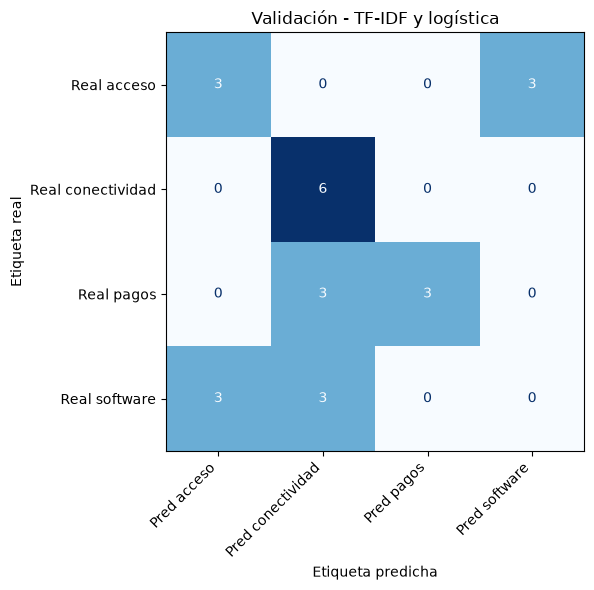

pagos: TP=3 FP=0 FN=3 TN=18
Precision manual = 1.0000
Recall    manual = 0.5000
Precision report = 1.0
Recall    report = 0.5
Comprobación OK: matriz y classification_report coinciden.


In [24]:
# Mostrar predicciones y la matriz de confusión
display(predicciones[["id", "text_original", "label", "prediction"]].head(6))

cm_val = confusion_matrix(val.label, pred_val, labels=LABELS)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val,
                              display_labels=LABELS)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

ax.set_xticklabels([f"Pred {c}" for c in LABELS], rotation=45, ha="right")
ax.set_yticklabels([f"Real {c}" for c in LABELS])
ax.set_xlabel("Etiqueta predicha")
ax.set_ylabel("Etiqueta real")
ax.set_title("Validación - TF-IDF y logística")
plt.tight_layout()
plt.show()

# Clase elegida para el ejercicio: pagos
clase = "pagos"
i = LABELS.index(clase)

tp = int(cm_val[i, i])
fp = int(cm_val[:, i].sum() - tp)
fn = int(cm_val[i, :].sum() - tp)
tn = int(cm_val.sum() - tp - fp - fn)

precision_manual = tp / (tp + fp) if (tp + fp) else 0.0
recall_manual    = tp / (tp + fn) if (tp + fn) else 0.0
print(f"{clase}: TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"Precision manual = {precision_manual:.4f}")
print(f"Recall    manual = {recall_manual:.4f}")

reporte = classification_report(val.label, pred_val, labels=LABELS,
                                output_dict=True, zero_division=0)
print("Precision report =", round(reporte[clase]["precision"], 4))
print("Recall    report =", round(reporte[clase]["recall"], 4))
assert np.isclose(precision_manual, reporte[clase]["precision"])
assert np.isclose(recall_manual,    reporte[clase]["recall"])
print("Comprobación OK: matriz y classification_report coinciden.")

**Mi interpretación:** 
Esta sección es útil para entender la eficiencia de nuestro entrenamiento, específicamente para la la clase *pagos*. Para ello se utiliza la matriz de confusión, la cual permite entender la fiabilidad del modelo al hacer predicciones al hacer una comparación entre los positivos verdaderos, falsos positivos, falsos negativos, verdaderos negativos. En este caso, al leer sus resultados es posible observar que 3 predicciones de pagos efectivamente eran pagos, mientras que otros 3 eran pagos pero se clasificaron como conectividad. 

Por otro lado, se utilizaron otras métricas para evaluar el entrenamiento como precisión y recall: con resultados de 1.0 y 0.5 respectivamente. Esto puede traducirse como que el modelo predice "pagos" acierta siempre, pero deja pasar la mitad de los pagos reales. La precisión de este caso no implica que la clase esté correctamente cubierta. 

### Trabajo 4: Diagnóstico

In [25]:
# 1) Identificar el error real (observación).
error = predicciones[predicciones.id.eq("S030")]
display(error)

# 2) Hipótesis: el término "autenticador" no fue aprendido en train,
#    así que el modelo no tiene señal léxica para asociarlo con "acceso".
print("¿'autenticador' está en el vocabulario de train?",
      "autenticador" in model["tfidf"].vocabulary_)

# 3) Evidencia: pesos TF-IDF de la fila y probabilidades por clase.
fila_err = model["tfidf"].transform([error.text_processed.iloc[0]]).getrow(0)
nombres = model["tfidf"].get_feature_names_out()
display(pd.DataFrame({"termino": nombres[fila_err.indices],
                      "peso": fila_err.data}).sort_values("peso", ascending=False).head(6))

proba_err = model.predict_proba([error.text_processed.iloc[0]])[0]
display(pd.DataFrame({"clase": LABELS, "probabilidad": proba_err}))

# 4) Caso exploratorio SEPARADO (no se añade a métricas).
exploratorio = "No me llega el código del autenticador y no puedo entrar."
print("Caso exploratorio (fuera de métricas):",
      exploratorio, "->", model.predict([exploratorio])[0])

,id,family,text_original,text_processed,label,prediction
29,S030,G010,El autenticador muestra un código inválido; ya...,El autenticador muestra un código inválido; ya...,acceso,software


¿'autenticador' está en el vocabulario de train? False


,termino,peso
0,código,0.484429
3,muestra,0.484429
7,un,0.378452
2,igual,0.240363
4,reinicié,0.240363
5,sigue,0.240363


,clase,probabilidad
0,acceso,0.247450
1,conectividad,0.157762
2,pagos,0.260859
3,software,0.333929


Caso exploratorio (fuera de métricas): No me llega el código del autenticador y no puedo entrar. -> acceso


**Mi interpretación:** El ejemplo anterior está clasificado erroneamente, esto puede estar relacionado con las palabras que detecta el modelo. Esto puede explicarse con lo siguiente:

- Observado: S030 se predice como software con prob 0.334 vs acceso 0.247. "autenticador" no está en vocabulario.
- Hipótesis 1: sin esa señal o texto, el modelo se apoya en "código", que en train puede asociarse más a software que en acceso.
- Hipótesis 2: la familia G010 usa "autenticador" y podría no estar representada en train.

## E. Guardar el Pipeline y documentar su origen
El archivo `baseline.skops` contiene vectorizador y clasificador ajustados. Guardar solo el clasificador perdería el vocabulario y sus IDF. El manifiesto registra versiones, datos, particiones y configuración.

Los archivos auxiliares se generan como apoyo guiado. La entrega sigue siendo el notebook con evidencia y explicación propias; no se añade un reporte obligatorio.

In [26]:
predicciones.to_csv(OUT/"predicciones.csv",index=False)
sio.dump(model,OUT/"baseline.skops")
manifiesto = {"versiones":versiones,"fuente":ARCHIVO.name,"sha256_datos":hashlib.sha256(ARCHIVO.read_bytes()).hexdigest(),
 "evaluacion":"validation; test no evaluado en el laboratorio","semilla":SEED,"orden_clases":LABELS,
 "ids_train":train.id.tolist(),"ids_validation":val.id.tolist(),
 "configuracion":{"vectorizador":"TF-IDF unigramas, L2, smooth_idf=True","clasificador":"LogisticRegression","C":1.0,"max_iter":1000,"solver":"lbfgs"}}
(OUT/"manifiesto.json").write_text(json.dumps(manifiesto,ensure_ascii=False,indent=2),encoding="utf-8")
(OUT/"metricas_validacion.json").write_text(json.dumps(resultado_val,ensure_ascii=False,indent=2),encoding="utf-8")
print("Guardados:",[p.name for p in OUT.iterdir() if p.is_file()])

Guardados: ['matriz_validacion.png', 'recarga.json', 'predicciones.csv', 'baseline.skops', 'verificar_recarga.py', 'metricas_validacion.json', 'manifiesto.json']


### El apoyo de recarga, con formato legible
Este programa se ejecutará en **otro proceso**: no hereda la variable `model` de este notebook.

1. Sustituye los métodos de entrenamiento por una función que falla si alguien intenta usarlos.
2. Inspecciona tipos antes de abrir el artefacto propio. Si aparecen tipos desconocidos, se detiene para revisión; no los autoriza automáticamente.
3. Carga el Pipeline, predice los mismos textos y compara todas las etiquetas.

El bloque entre comillas es el contenido legible del archivo de apoyo; no necesitas subir otro archivo a Colab.

In [27]:
script_recarga = r'''
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import skops.io as sio
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def prohibido(*args, **kwargs):
    raise RuntimeError("Esta prueba prohíbe volver a entrenar")

# Entrenar o reajustar una representación debe fallar en este proceso.
Pipeline.fit = prohibido
TfidfVectorizer.fit = prohibido
TfidfVectorizer.fit_transform = prohibido
LogisticRegression.fit = prohibido

carpeta = Path(sys.argv[1])
tipos = sio.get_untrusted_types(file=carpeta/"baseline.skops")
if tipos:
    raise RuntimeError("Revisar tipos antes de autorizar carga: "+str(tipos))
recuperado = sio.load(carpeta/"baseline.skops", trusted=[])
referencia = pd.read_csv(carpeta/"predicciones.csv", keep_default_na=False)
observadas = recuperado.predict(referencia.text_processed).tolist()
assert observadas == referencia.prediction.tolist(), "Cambió alguna predicción"
resultado = {"estado":"PASS", "filas":len(referencia), "fit_prohibido":True,
             "tipos_no_confiables":tipos}
(carpeta/"recarga.json").write_text(json.dumps(resultado,indent=2))
print(json.dumps(resultado))
'''
(OUT/"verificar_recarga.py").write_text(script_recarga,encoding="utf-8")

1238

In [28]:
proceso = subprocess.run([sys.executable,str(OUT/"verificar_recarga.py"),str(OUT)],
                         capture_output=True,text=True)
if proceso.returncode:
    raise RuntimeError("Falló la recarga en otro proceso:\n"+proceso.stderr)
print(proceso.stdout)
recarga_observada = json.loads((OUT/"recarga.json").read_text())
assert recarga_observada["fit_prohibido"] and recarga_observada["filas"] == len(val)
completados.add(6)

{"estado": "PASS", "filas": 24, "fit_prohibido": true, "tipos_no_confiables": []}



**Cómo leer la salida.** PASS significa que todas las predicciones coincidieron y que la prueba prohibió el entrenamiento. No demuestra buena clasificación ni generalización. Descargar solo el notebook no conserva el modelo temporal de Colab: descarga también los archivos que quieras reutilizar.

## Cierre
Explica dónde aprende cada componente, qué representa una celda de la matriz, qué distingue precision de recall y qué prueba la recarga. La comparación entre logística y NB y la evaluación final de test corresponden a Actividad 2, con su propio corpus y protocolo.

**¿Dónde aprende cada componente?**

En el pipeline existen dos etapas donde se aprenden cosas distintas:
1. En el vectorizador TF-IDF: Se aprende el texto de train al construir el vocabulario y calcular los valores IDF de cada término con base en frecuencia de apariciones. 
2. En el clasificador de regresión logística: Aprende de los vectores TF-IDF y de las etiquetas de train al ajustar un peso por clase por cada término

**¿Qué representa una celda de la matriz?**

Cada celda (i, j) de la matriz de confusión cuenta cuántos casos con etiqueta real i fueron predichos como clase j:
- La diagonal representa la convergencia de lo real y lo predicho.
- Fuera de la diagonal son errores.
- La suma de una fila es el número de casos reales de esa clase.
- La suma de una columna es cuántas veces se predijo esa clase.

**¿Qué distingue precision de recall?**

- Precision = TP / (TP + FP). Evalúa qué tan confiable es el modelo cuando predice esta clase.
- Recall = TP / (TP + FN). Evalúa qué tanto falla en identificar los casos reales.

**¿Qué prueba la recarga?**
El script `verificar_recarga.py` se ejecuta en otro proceso y comprueba tres cosas:
1. Se cuenta con pipeline (vectorizador + clasificador), no solo el clasificador.
2. No se puede volver a entrenar en ese proceso. Cargar y predecir es lo único permitido.
3. Las predicciones deben coincidir con las guardadas en `predicciones.csv`.

Referencias: [Naive Bayes](https://scikit-learn.org/stable/modules/naive_bayes.html), [logística](https://scikit-learn.org/1.6/modules/generated/sklearn.linear_model.LogisticRegression.html), [métricas](https://scikit-learn.org/1.6/modules/generated/sklearn.metrics.precision_recall_fscore_support.html), [skops](https://skops.readthedocs.io/en/stable/persistence.html). El entorno local de referencia usa scikit-learn 1.6.1 y skops 0.11.0; registra las versiones de tu ejecución.

**Declaración de Uso de IA**

Herramienta: DeepSeek

Uso realizado: Asistencia en la modificación y adaptación del código proporcionado por mí. Concretamente se le proporcionó pseudocódigo, secciones de código de las clases e instrucciones específicas sobre los cambios requeridos y su propósito, y se utilizó la herramienta para proponer e implementar dichas modificaciones.

Secciones donde se utilizó: Todas las secciones de la actividad en las que se requirieron modificaciones, implementación o ajustes de código.

Validación realizada por el estudiante: Se revisó el código generado o modificado, verificando que correspondiera con las instrucciones y requerimientos de la actividad, así como su integración con el código proporcionado previamente.

Otro (especifique): La IA se utilizó como herramienta de apoyo y no como sustituto de mi trabajo. Las instrucciones, código base y requerimientos de modificación fueron proporcionados por mí.

Confirmación: Confirmo que revisé, verifiqué y asumo la responsabilidad del contenido final entregado.
